In [10]:
import sys

!{sys.executable} -m pip install fastparquet


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



   ---------------------------------------- 0.0/695.7 kB ? eta -:--:--
   ---------------------------------------- 695.7/695.7 kB 4.6 MB/s  0:00:00
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------------------ --------- 1.3/1.7 MB 6.7 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 6.2 MB/s  0:00:00

   -------------------- ------------------- 1/2 [fastparquet]
   -------------------- ------------------- 1/2 [fastparquet]
   -------------------- ------------------- 1/2 [fastparquet]
   -------------------- ------------------- 1/2 [fastparquet]
   -------------------- ------------------- 1/2 [fastparquet]
   -------------------- ------------------- 1/2 [fastparquet]
   ---------------------------------------- 2/2 [fastparquet]



In [11]:
# ============================================================
# WEEK 7 — K-Means Clustering on PCA Components
# F1 Race Intelligence & Strategic Optimization
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style("darkgrid")
sns.set_palette("tab10")

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


In [12]:
# ------------------------------------------------------------
# Load PCA scores (output from PCA_V3.ipynb)
# 643 tactical events × 15 principal components
# ------------------------------------------------------------
from pathlib import Path
import pandas as pd

def find_project_root():
    current = Path.cwd().resolve()

    for path in [current, *current.parents]:
        if (path / "data" / "features" / "pca_scores.parquet").exists():
            return path
        
        if (path / "project" / "data" / "features" / "pca_scores.parquet").exists():
            return path / "project"

    raise FileNotFoundError("No se encontró la carpeta del proyecto con data/features/pca_scores.parquet")

BASE_DIR = find_project_root()

PCA_PATH = BASE_DIR / "data" / "features" / "pca_scores.parquet"
MASTER_PATH = BASE_DIR / "data" / "processed" / "tactical_events" / "tactical_events_master.parquet"

print("BASE_DIR:", BASE_DIR)
print("PCA_PATH existe:", PCA_PATH.exists())
print("MASTER_PATH existe:", MASTER_PATH.exists())

df_pca = pd.read_parquet(PCA_PATH, engine="fastparquet")
df_master = pd.read_parquet(MASTER_PATH, engine="fastparquet")

print(f"PCA scores shape: {df_pca.shape}")
print(f"Tactical master shape: {df_master.shape}")

print(f"\nPCA columns: {list(df_pca.columns)}")
print(f"\nEvent types distribution:\n{df_pca['event_type'].value_counts()}")
print(f"\nRaces distribution:\n{df_pca['race_name'].value_counts()}")

df_pca.head(3)

BASE_DIR: C:\Users\rgame\OneDrive\Documentos\GitHub\F1-data-project\project
PCA_PATH existe: True
MASTER_PATH existe: True
PCA scores shape: (643, 18)
Tactical master shape: (234, 186)

PCA columns: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'event_id', 'race_name', 'event_type']

Event types distribution:
event_type
On_Track_Overtake    584
Pit_Strategy          59
Name: count, dtype: int64

Races distribution:
race_name
united_states_2026    409
australia_2026        120
china_2026             61
japan_2026             53
Name: count, dtype: int64


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,event_id,race_name,event_type
0,-13.991860,0.179031,-2.593787,4.837801,-2.197932,1.576668,-4.691163,-3.296525,2.361068,2.612416,1.466017,0.787531,-1.587873,5.942348,1.488244,australia_2026_L4.0_1.0v10.0,australia_2026,On_Track_Overtake
1,-12.109794,0.980667,-1.768045,4.565313,-2.040495,0.430619,-1.449882,-2.468387,-1.446526,2.670905,1.883367,1.993196,-2.811361,5.017712,1.505414,australia_2026_L4.0_1.0v87.0,australia_2026,On_Track_Overtake
2,-12.582787,1.097047,-2.122164,4.483317,-4.388388,6.310415,-1.662287,-3.031473,-4.162519,4.042691,1.743304,2.342860,-2.257137,5.853892,3.961440,australia_2026_L4.0_1.0v5.0,australia_2026,On_Track_Overtake


In [13]:
# ------------------------------------------------------------
# Extract the 15 PCA components as the feature matrix X
# These are already scaled (mean=0, std=1) from PCA pipeline
# ------------------------------------------------------------

PC_COLS = [f"PC{i}" for i in range(1, 16)]

X = df_pca[PC_COLS].values

print(f"Feature matrix X shape: {X.shape}")
print(f"Using components: {PC_COLS}")
print(f"\nBasic stats per component (should be ~0 mean, unit variance):")
pd.DataFrame(X, columns=PC_COLS).describe().loc[['mean','std','min','max']].round(3)

Feature matrix X shape: (643, 15)
Using components: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15']

Basic stats per component (should be ~0 mean, unit variance):


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15
mean,-0.000,-0.000,0.000,-0.000,0.000,-0.000,-0.000,0.000,0.000,-0.000,0.000,0.000,0.000,0.000,0.000
std,11.336,6.941,5.291,4.418,4.242,3.728,3.579,3.398,3.276,3.150,3.093,2.985,2.894,2.790,2.728
min,-14.471,-20.388,-20.111,-12.334,-16.245,-11.753,-11.752,-3.553,-6.874,-8.825,-15.598,-9.295,-8.777,-8.261,-7.257
max,17.157,10.852,10.994,12.330,14.270,14.209,13.772,55.694,12.560,10.187,8.529,7.128,8.902,9.433,8.711


In [14]:
# ============================================================
# PARAMETER SWEEP — K from 2 to 10
# The professor requires showing the sweep, not just one k
# ============================================================

K_RANGE = range(2, 11)
RANDOM_STATE = 42
N_INIT = 20  # multiple initializations for stability

inertias = []
silhouette_scores = []
calinski_scores = []
davies_bouldin_scores = []

print("Running K-Means sweep...")
print(f"{'k':>4} | {'Inertia':>12} | {'Silhouette':>12} | {'Calinski-H':>12} | {'Davies-B':>10}")
print("-" * 60)

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=N_INIT,
                max_iter=500, random_state=RANDOM_STATE)
    labels = km.fit_predict(X)
    
    inertia = km.inertia_
    sil = silhouette_score(X, labels)
    cal = calinski_harabasz_score(X, labels)
    dav = davies_bouldin_score(X, labels)
    
    inertias.append(inertia)
    silhouette_scores.append(sil)
    calinski_scores.append(cal)
    davies_bouldin_scores.append(dav)
    
    print(f"{k:>4} | {inertia:>12.1f} | {sil:>12.4f} | {cal:>12.2f} | {dav:>10.4f}")

print("\n✅ Sweep complete")

Running K-Means sweep...
   k |      Inertia |   Silhouette |   Calinski-H |   Davies-B
------------------------------------------------------------
   2 |     143810.4 |       0.3721 |       341.04 |     1.3103
   3 |     117558.9 |       0.4113 |       279.73 |     1.1696
   4 |     105847.6 |       0.3910 |       230.36 |     1.4782
   5 |      94836.2 |       0.2450 |       211.05 |     1.6376
   6 |      86211.1 |       0.2531 |       198.19 |     1.5755
   7 |      79229.8 |       0.2610 |       188.77 |     1.3640
   8 |      73446.2 |       0.2725 |       181.41 |     1.2640
   9 |      69050.4 |       0.2812 |       173.62 |     1.2454
  10 |      65557.6 |       0.2819 |       166.04 |     1.2649

✅ Sweep complete


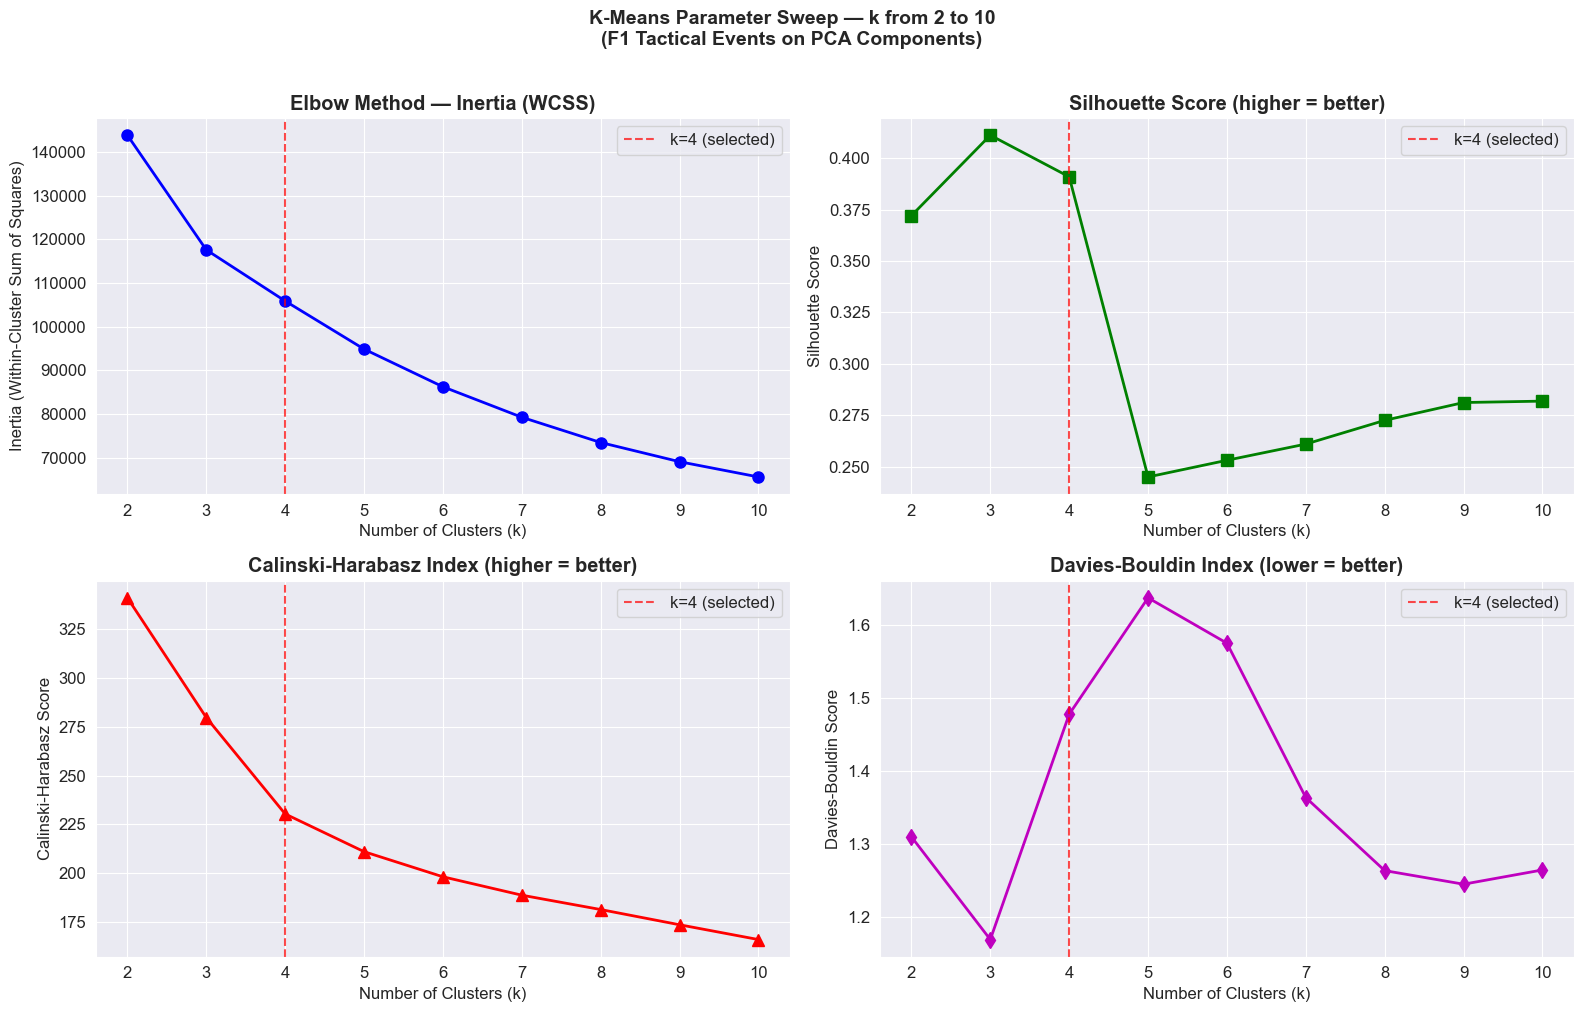

✅ Saved: C:\Users\rgame\OneDrive\Documentos\GitHub\F1-data-project\project\artifacts\kmeans_parameter_sweep.png


In [16]:
# ------------------------------------------------------------
# Visualize all 4 metrics across the parameter sweep
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("K-Means Parameter Sweep — k from 2 to 10\n(F1 Tactical Events on PCA Components)",
             fontsize=14, fontweight='bold', y=1.01)

k_vals = list(K_RANGE)

# 1. Elbow (Inertia)
ax1 = axes[0, 0]
ax1.plot(k_vals, inertias, 'bo-', linewidth=2, markersize=8)
ax1.axvline(x=4, color='red', linestyle='--', alpha=0.7, label='k=4 (selected)')
ax1.set_title("Elbow Method — Inertia (WCSS)", fontweight='bold')
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia (Within-Cluster Sum of Squares)")
ax1.legend()
ax1.set_xticks(k_vals)

# 2. Silhouette Score
ax2 = axes[0, 1]
ax2.plot(k_vals, silhouette_scores, 'gs-', linewidth=2, markersize=8)
ax2.axvline(x=4, color='red', linestyle='--', alpha=0.7, label='k=4 (selected)')
ax2.set_title("Silhouette Score (higher = better)", fontweight='bold')
ax2.set_xlabel("Number of Clusters (k)")
ax2.set_ylabel("Silhouette Score")
ax2.legend()
ax2.set_xticks(k_vals)

# 3. Calinski-Harabasz
ax3 = axes[1, 0]
ax3.plot(k_vals, calinski_scores, 'r^-', linewidth=2, markersize=8)
ax3.axvline(x=4, color='red', linestyle='--', alpha=0.7, label='k=4 (selected)')
ax3.set_title("Calinski-Harabasz Index (higher = better)", fontweight='bold')
ax3.set_xlabel("Number of Clusters (k)")
ax3.set_ylabel("Calinski-Harabasz Score")
ax3.legend()
ax3.set_xticks(k_vals)

# 4. Davies-Bouldin
ax4 = axes[1, 1]
ax4.plot(k_vals, davies_bouldin_scores, 'md-', linewidth=2, markersize=8)
ax4.axvline(x=4, color='red', linestyle='--', alpha=0.7, label='k=4 (selected)')
ax4.set_title("Davies-Bouldin Index (lower = better)", fontweight='bold')
ax4.set_xlabel("Number of Clusters (k)")
ax4.set_ylabel("Davies-Bouldin Score")
ax4.legend()
ax4.set_xticks(k_vals)
from pathlib import Path

plt.tight_layout()

ARTIFACTS_DIR = BASE_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

output_path = ARTIFACTS_DIR / "kmeans_parameter_sweep.png"

plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Saved: {output_path}")

In [17]:
# ------------------------------------------------------------
# Full validation table — all k values with all metrics
# ------------------------------------------------------------

sweep_df = pd.DataFrame({
    'k': k_vals,
    'Inertia (WCSS)': [round(v, 1) for v in inertias],
    'Silhouette Score': [round(v, 4) for v in silhouette_scores],
    'Calinski-Harabasz': [round(v, 2) for v in calinski_scores],
    'Davies-Bouldin': [round(v, 4) for v in davies_bouldin_scores],
})

# Highlight best values
def highlight_best(s):
    if s.name == 'Silhouette Score' or s.name == 'Calinski-Harabasz':
        best = s.max()
        return ['background-color: #c6efce; font-weight: bold' if v == best else '' for v in s]
    elif s.name == 'Davies-Bouldin':
        best = s.min()
        return ['background-color: #c6efce; font-weight: bold' if v == best else '' for v in s]
    else:
        return ['' for _ in s]

print("=" * 70)
print("VALIDATION TABLE — K-Means Parameter Sweep")
print("=" * 70)
print(sweep_df.to_string(index=False))
print("=" * 70)
print("\n⚠️  Interpretation limits:")
print("  • Silhouette > 0.5 = strong separation; 0.25–0.5 = moderate (expected in high-dim)")
print("  • Inertia: look for the 'elbow' — the point of diminishing returns")
print("  • Calinski-Harabasz: ratio of between/within cluster variance")
print("  • Davies-Bouldin: average cluster-to-cluster similarity (lower = more distinct)")

sweep_df.style.apply(highlight_best)

VALIDATION TABLE — K-Means Parameter Sweep
 k  Inertia (WCSS)  Silhouette Score  Calinski-Harabasz  Davies-Bouldin
 2        143810.4            0.3721             341.04          1.3103
 3        117558.9            0.4113             279.73          1.1696
 4        105847.6            0.3910             230.36          1.4782
 5         94836.2            0.2450             211.05          1.6376
 6         86211.1            0.2531             198.19          1.5755
 7         79229.8            0.2610             188.77          1.3640
 8         73446.2            0.2725             181.41          1.2640
 9         69050.4            0.2812             173.62          1.2454
10         65557.6            0.2819             166.04          1.2649

⚠️  Interpretation limits:
  • Silhouette > 0.5 = strong separation; 0.25–0.5 = moderate (expected in high-dim)
  • Inertia: look for the 'elbow' — the point of diminishing returns
  • Calinski-Harabasz: ratio of between/within cluster 

,k,Inertia (WCSS),Silhouette Score,Calinski-Harabasz,Davies-Bouldin
0,2,143810.400000,0.372100,341.040000,1.310300
1,3,117558.900000,0.411300,279.730000,1.169600
2,4,105847.600000,0.391000,230.360000,1.478200
3,5,94836.200000,0.245000,211.050000,1.637600
4,6,86211.100000,0.253100,198.190000,1.575500
5,7,79229.800000,0.261000,188.770000,1.364000
6,8,73446.200000,0.272500,181.410000,1.264000
7,9,69050.400000,0.281200,173.620000,1.245400
8,10,65557.600000,0.281900,166.040000,1.264900


In [18]:
# ============================================================
# FINAL MODEL — K-Means with k=4
# Justification: elbow inflection + alignment with Hierarchical
# k=4 selected from sweep; also matches domain (4 tactical archetypes)
# ============================================================

K_OPTIMAL = 4  # justified by sweep above

kmeans_final = KMeans(
    n_clusters=K_OPTIMAL,
    init='k-means++',   # smart centroid initialization
    n_init=50,          # more inits for final model stability
    max_iter=1000,
    random_state=42
)

kmeans_final.fit(X)
df_pca['kmeans_cluster'] = kmeans_final.labels_

print(f"✅ Final K-Means model fitted with k={K_OPTIMAL}")
print(f"\nCluster distribution:")
print(df_pca['kmeans_cluster'].value_counts().sort_index())
print(f"\nCluster sizes (%):")
print((df_pca['kmeans_cluster'].value_counts(normalize=True).sort_index() * 100).round(1))

# Final model metrics
final_sil = silhouette_score(X, kmeans_final.labels_)
final_cal = calinski_harabasz_score(X, kmeans_final.labels_)
final_dav = davies_bouldin_score(X, kmeans_final.labels_)

print(f"\n{'='*45}")
print(f"FINAL MODEL METRICS (k={K_OPTIMAL})")
print(f"{'='*45}")
print(f"  Inertia (WCSS)       : {kmeans_final.inertia_:,.1f}")
print(f"  Silhouette Score     : {final_sil:.4f}")
print(f"  Calinski-Harabasz    : {final_cal:.2f}")
print(f"  Davies-Bouldin       : {final_dav:.4f}")

✅ Final K-Means model fitted with k=4

Cluster distribution:
kmeans_cluster
0     82
1    378
2     65
3    118
Name: count, dtype: int64

Cluster sizes (%):
kmeans_cluster
0    12.8
1    58.8
2    10.1
3    18.4
Name: proportion, dtype: float64

FINAL MODEL METRICS (k=4)
  Inertia (WCSS)       : 105,847.6
  Silhouette Score     : 0.3910
  Calinski-Harabasz    : 230.36
  Davies-Bouldin       : 1.4782


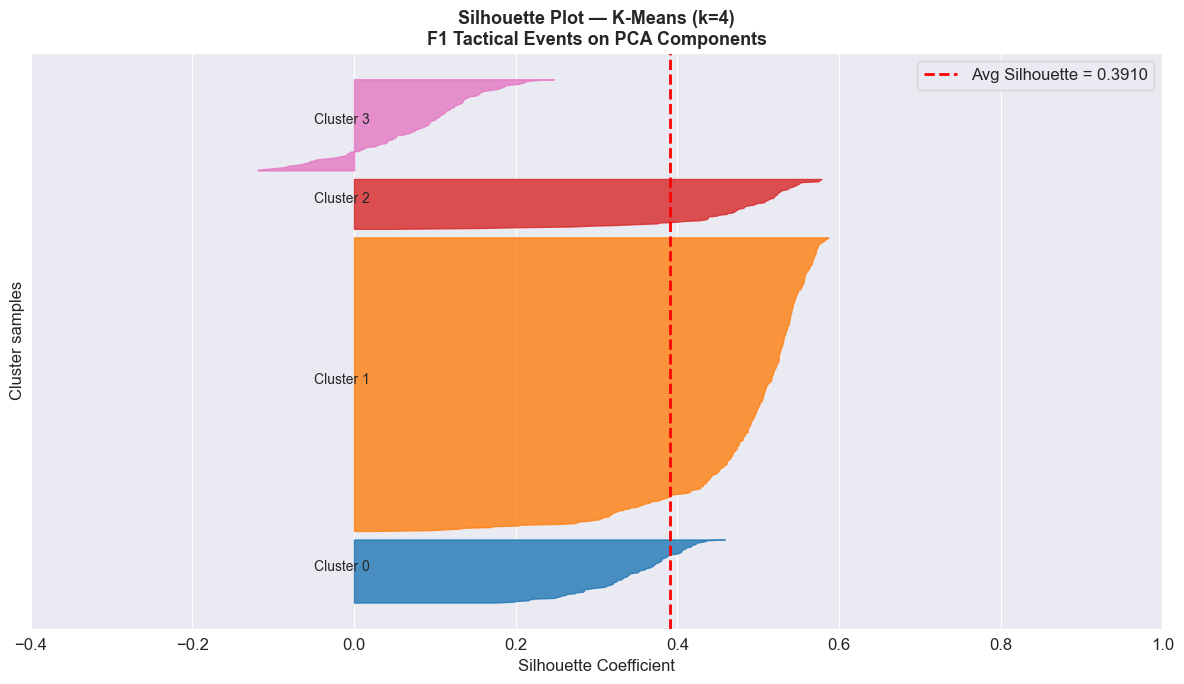

✅ Saved: C:\Users\rgame\OneDrive\Documentos\GitHub\F1-data-project\project\artifacts\kmeans_silhouette_plot.png


In [20]:
# ------------------------------------------------------------
# Silhouette plot — visualize per-sample cohesion
# Shows which points cluster well and which are borderline
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 7))

sample_sil_values = silhouette_samples(X, kmeans_final.labels_)
y_lower = 10

colors = cm.tab10(np.linspace(0, 0.6, K_OPTIMAL))

for i in range(K_OPTIMAL):
    cluster_sil = sample_sil_values[kmeans_final.labels_ == i]
    cluster_sil.sort()
    
    size_i = len(cluster_sil)
    y_upper = y_lower + size_i
    
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                     facecolor=colors[i], edgecolor=colors[i], alpha=0.8)
    ax.text(-0.05, y_lower + 0.5 * size_i, f"Cluster {i}", fontsize=10)
    y_lower = y_upper + 10

ax.axvline(x=final_sil, color="red", linestyle="--", linewidth=2,
           label=f"Avg Silhouette = {final_sil:.4f}")

ax.set_title(f"Silhouette Plot — K-Means (k={K_OPTIMAL})\nF1 Tactical Events on PCA Components",
             fontweight='bold', fontsize=13)
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster samples")
ax.set_yticks([])
ax.set_xlim(-0.4, 1.0)
ax.legend(loc='upper right')
ax.set_xticks([-0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1.0])


from pathlib import Path

plt.tight_layout()

ARTIFACTS_DIR = BASE_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

output_path = ARTIFACTS_DIR / "kmeans_silhouette_plot.png"

plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Saved: {output_path}")

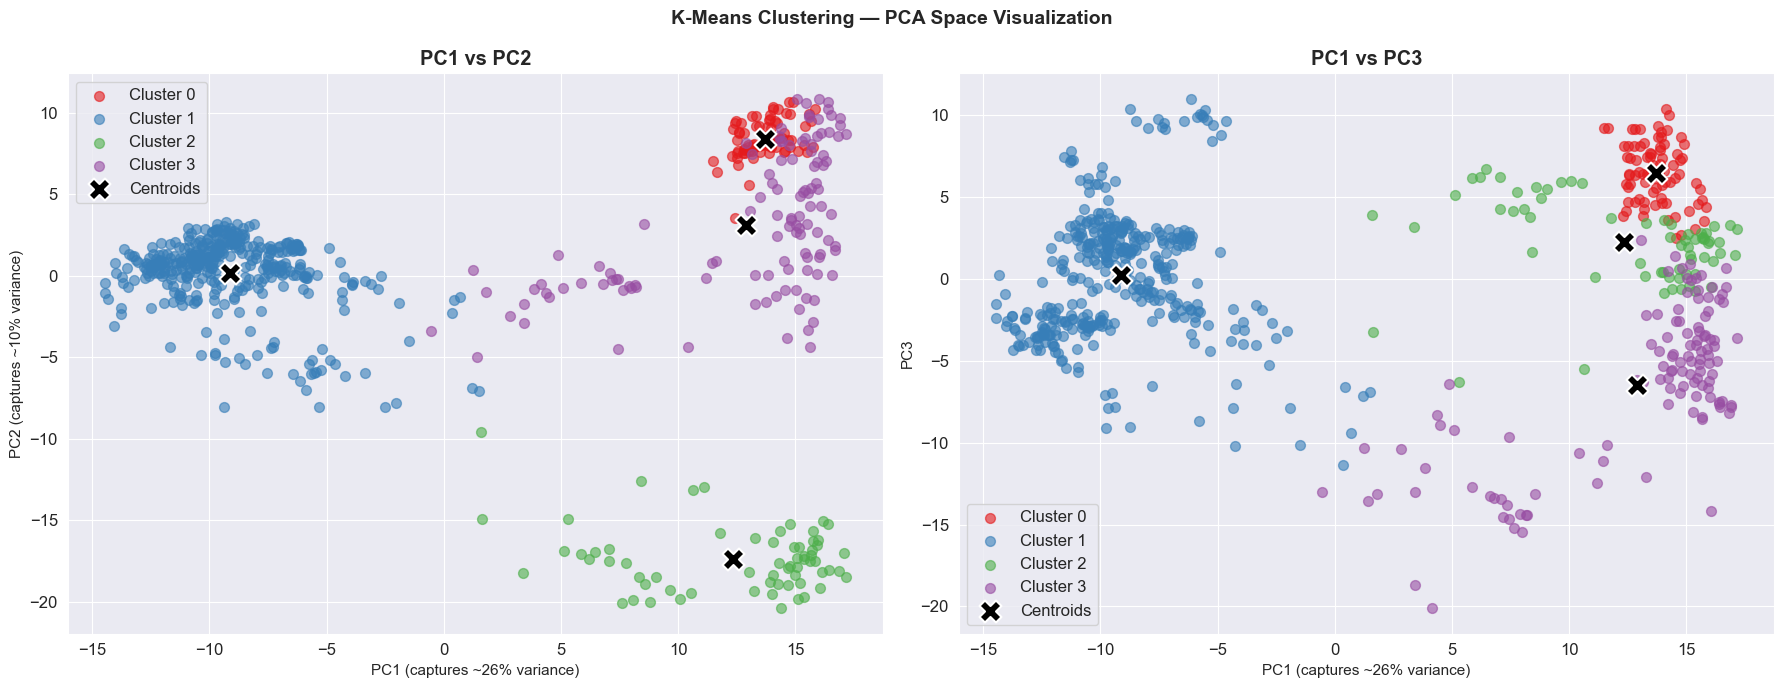

✅ Saved: C:\Users\rgame\OneDrive\Documentos\GitHub\F1-data-project\project\artifacts\kmeans_scatter_pca.png


In [21]:
# ------------------------------------------------------------
# 2D scatter: PC1 vs PC2, colored by K-Means cluster
# Centroids plotted as black X markers
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("K-Means Clustering — PCA Space Visualization", fontsize=14, fontweight='bold')

colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
cluster_names_temp = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

# Left: PC1 vs PC2
ax1 = axes[0]
for c in range(K_OPTIMAL):
    mask = df_pca['kmeans_cluster'] == c
    ax1.scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
                c=colors[c], label=cluster_names_temp[c], alpha=0.6, s=50)

# Plot centroids
centroids = kmeans_final.cluster_centers_
ax1.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X',
            s=250, zorder=5, label='Centroids', edgecolors='white', linewidths=1.5)

ax1.set_xlabel("PC1 (captures ~26% variance)", fontsize=11)
ax1.set_ylabel("PC2 (captures ~10% variance)", fontsize=11)
ax1.set_title("PC1 vs PC2", fontweight='bold')
ax1.legend()

# Right: PC1 vs PC3
ax2 = axes[1]
for c in range(K_OPTIMAL):
    mask = df_pca['kmeans_cluster'] == c
    ax2.scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC3'],
                c=colors[c], label=cluster_names_temp[c], alpha=0.6, s=50)

ax2.scatter(centroids[:, 0], centroids[:, 2], c='black', marker='X',
            s=250, zorder=5, label='Centroids', edgecolors='white', linewidths=1.5)

ax2.set_xlabel("PC1 (captures ~26% variance)", fontsize=11)
ax2.set_ylabel("PC3", fontsize=11)
ax2.set_title("PC1 vs PC3", fontweight='bold')
ax2.legend()

from pathlib import Path

plt.tight_layout()

ARTIFACTS_DIR = BASE_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

output_path = ARTIFACTS_DIR / "kmeans_scatter_pca.png"

plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Saved: {output_path}")

In [22]:
# ============================================================
# CLUSTER PROFILE ANALYSIS
# Characterize each cluster using PCA component means
# and cross-reference with metadata (race, event_type)
# ============================================================

# Profile by PCA components (centroid coordinates)
centroid_df = pd.DataFrame(kmeans_final.cluster_centers_, columns=PC_COLS)
centroid_df.index.name = 'cluster'
centroid_df.index = [f"Cluster {i}" for i in range(K_OPTIMAL)]

print("=" * 60)
print("CENTROID COORDINATES (mean in PCA space per cluster)")
print("=" * 60)
print(centroid_df[['PC1','PC2','PC3','PC4','PC5']].round(3).to_string())

# Profile by metadata
print("\n" + "=" * 60)
print("CLUSTER PROFILES — Metadata Cross-Reference")
print("=" * 60)

for c in range(K_OPTIMAL):
    cluster_mask = df_pca['kmeans_cluster'] == c
    cluster_data = df_pca[cluster_mask]
    
    print(f"\n--- Cluster {c} (n={cluster_mask.sum()}) ---")
    print(f"  Event types : {cluster_data['event_type'].value_counts().to_dict()}")
    print(f"  Races       : {cluster_data['race_name'].value_counts().to_dict()}")
    print(f"  PC1 mean    : {cluster_data['PC1'].mean():.3f} (population mean: 0)")
    print(f"  PC2 mean    : {cluster_data['PC2'].mean():.3f}")
    print(f"  PC3 mean    : {cluster_data['PC3'].mean():.3f}")

CENTROID COORDINATES (mean in PCA space per cluster)
              PC1     PC2    PC3    PC4    PC5
Cluster 0  13.691   8.408  6.489  3.265  0.781
Cluster 1  -9.111   0.193  0.238 -0.138 -0.186
Cluster 2  12.338 -17.351  2.231  1.100  1.341
Cluster 3  12.877   3.097 -6.500 -2.431 -0.687

CLUSTER PROFILES — Metadata Cross-Reference

--- Cluster 0 (n=82) ---
  Event types : {'On_Track_Overtake': 82}
  Races       : {'united_states_2026': 82}
  PC1 mean    : 13.691 (population mean: 0)
  PC2 mean    : 8.408
  PC3 mean    : 6.489

--- Cluster 1 (n=378) ---
  Event types : {'On_Track_Overtake': 320, 'Pit_Strategy': 58}
  Races       : {'united_states_2026': 166, 'australia_2026': 116, 'china_2026': 51, 'japan_2026': 45}
  PC1 mean    : -9.111 (population mean: 0)
  PC2 mean    : 0.193
  PC3 mean    : 0.238

--- Cluster 2 (n=65) ---
  Event types : {'On_Track_Overtake': 65}
  Races       : {'united_states_2026': 58, 'japan_2026': 4, 'china_2026': 3}
  PC1 mean    : 12.338 (population mean: 0

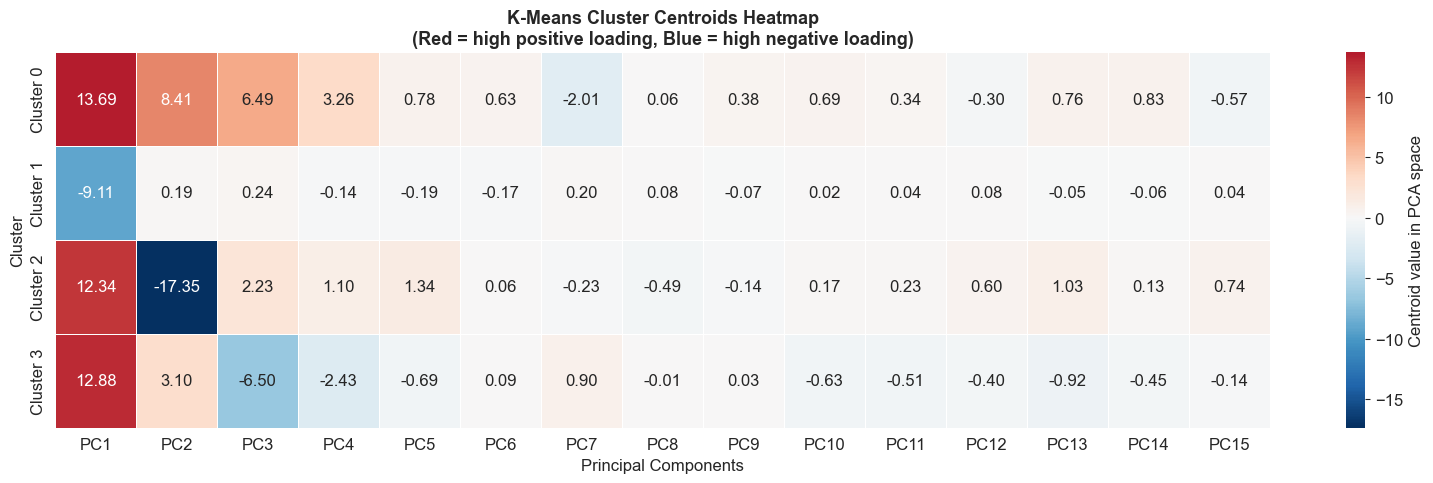

✅ Saved: C:\Users\rgame\OneDrive\Documentos\GitHub\F1-data-project\project\artifacts\kmeans_centroid_heatmap.png


In [24]:
# ------------------------------------------------------------
# Heatmap: centroid values across PC1–PC15
# Shows which components drive each cluster
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(16, 5))

sns.heatmap(centroid_df,
            annot=True, fmt=".2f", cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Centroid value in PCA space'})

ax.set_title("K-Means Cluster Centroids Heatmap\n(Red = high positive loading, Blue = high negative loading)",
             fontweight='bold', fontsize=13)
ax.set_xlabel("Principal Components")
ax.set_ylabel("Cluster")

from pathlib import Path

plt.tight_layout()

ARTIFACTS_DIR = BASE_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

output_path = ARTIFACTS_DIR / "kmeans_centroid_heatmap.png"

plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Saved: {output_path}")

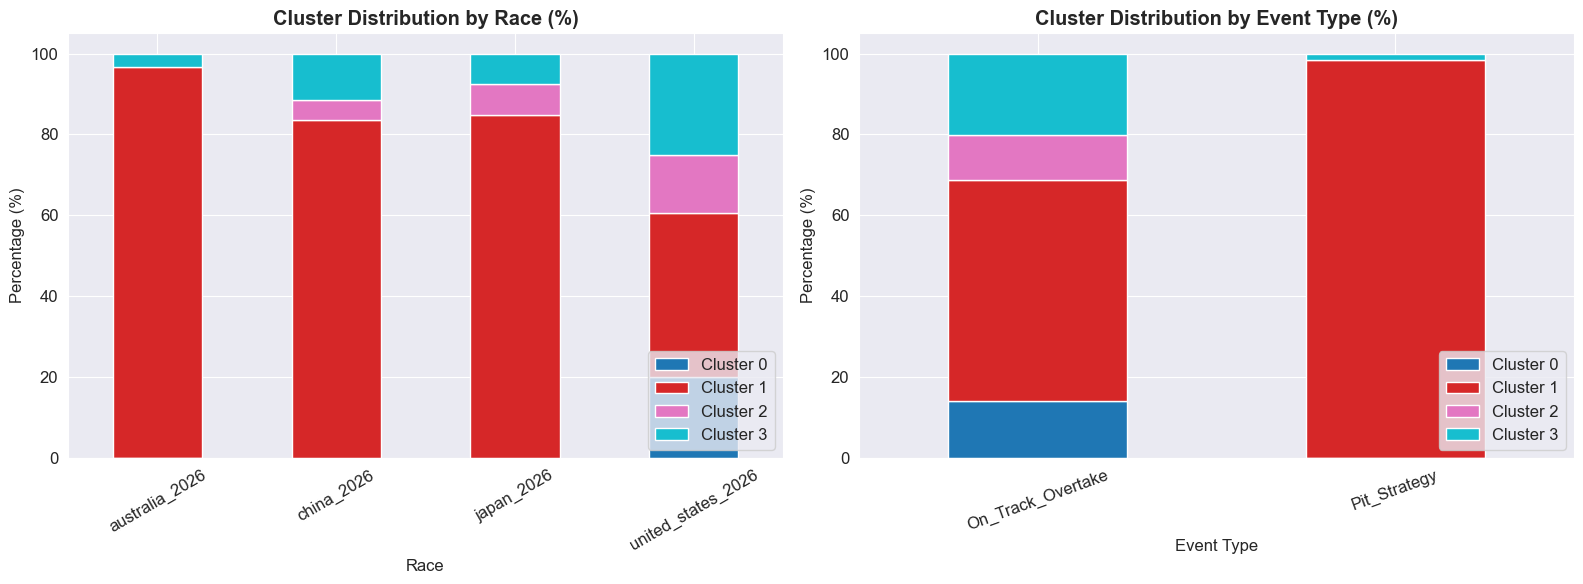

✅ Saved: C:\Users\rgame\OneDrive\Documentos\GitHub\F1-data-project\project\artifacts\kmeans_cluster_distribution.png


In [25]:
# ------------------------------------------------------------
# Cross-tabulation: cluster vs race and event type
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Stacked bar: cluster distribution by race
race_cluster = pd.crosstab(df_pca['race_name'], df_pca['kmeans_cluster'], normalize='index') * 100
race_cluster.columns = [f"Cluster {c}" for c in race_cluster.columns]
race_cluster.plot(kind='bar', stacked=True, ax=axes[0], colormap='tab10', edgecolor='white')
axes[0].set_title("Cluster Distribution by Race (%)", fontweight='bold')
axes[0].set_xlabel("Race")
axes[0].set_ylabel("Percentage (%)")
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(loc='lower right')

# Stacked bar: cluster distribution by event type
type_cluster = pd.crosstab(df_pca['event_type'], df_pca['kmeans_cluster'], normalize='index') * 100
type_cluster.columns = [f"Cluster {c}" for c in type_cluster.columns]
type_cluster.plot(kind='bar', stacked=True, ax=axes[1], colormap='tab10', edgecolor='white')
axes[1].set_title("Cluster Distribution by Event Type (%)", fontweight='bold')
axes[1].set_xlabel("Event Type")
axes[1].set_ylabel("Percentage (%)")
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(loc='lower right')

from pathlib import Path

plt.tight_layout()

ARTIFACTS_DIR = BASE_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

output_path = ARTIFACTS_DIR / "kmeans_cluster_distribution.png"

plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Saved: {output_path}")

In [26]:
# ============================================================
# FAILURE ANALYSIS
# Identify points that clustered poorly (negative silhouette)
# and understand why they don't fit well
# ============================================================

sample_sil = silhouette_samples(X, kmeans_final.labels_)
df_pca['sil_score'] = sample_sil

# Failed points: negative silhouette = closer to another cluster
failed = df_pca[df_pca['sil_score'] < 0].copy()
borderline = df_pca[(df_pca['sil_score'] >= 0) & (df_pca['sil_score'] < 0.1)].copy()
well_clustered = df_pca[df_pca['sil_score'] >= 0.3].copy()

print("=" * 55)
print("FAILURE ANALYSIS — Silhouette-based Point Quality")
print("=" * 55)
print(f"  ✅ Well-clustered   (sil ≥ 0.30) : {len(well_clustered):>4} points ({len(well_clustered)/len(df_pca)*100:.1f}%)")
print(f"  ⚠️  Borderline      (0 ≤ sil < 0.10): {len(borderline):>4} points ({len(borderline)/len(df_pca)*100:.1f}%)")
print(f"  ❌ Misassigned      (sil < 0)    : {len(failed):>4} points ({len(failed)/len(df_pca)*100:.1f}%)")
print()

print("Failed points by cluster:")
print(failed['kmeans_cluster'].value_counts().sort_index())
print()
print("Failed points by event type:")
print(failed['event_type'].value_counts())
print()
print("Failed points by race:")
print(failed['race_name'].value_counts())
print()

# Distribution of silhouette scores
print("Silhouette score distribution per cluster:")
print(df_pca.groupby('kmeans_cluster')['sil_score'].describe().round(4))

FAILURE ANALYSIS — Silhouette-based Point Quality
  ✅ Well-clustered   (sil ≥ 0.30) :  485 points (75.4%)
  ⚠️  Borderline      (0 ≤ sil < 0.10):   43 points (6.7%)
  ❌ Misassigned      (sil < 0)    :   25 points (3.9%)

Failed points by cluster:
kmeans_cluster
3    25
Name: count, dtype: int64

Failed points by event type:
event_type
On_Track_Overtake    24
Pit_Strategy          1
Name: count, dtype: int64

Failed points by race:
race_name
united_states_2026    17
australia_2026         4
china_2026             2
japan_2026             2
Name: count, dtype: int64

Silhouette score distribution per cluster:
                count    mean     std     min     25%     50%     75%     max
kmeans_cluster                                                               
0                82.0  0.3430  0.0640  0.1749  0.3095  0.3518  0.3890  0.4586
1               378.0  0.4872  0.0870  0.0259  0.4654  0.5115  0.5412  0.5867
2                65.0  0.4685  0.0999  0.0466  0.4389  0.4961  0.5269  0.

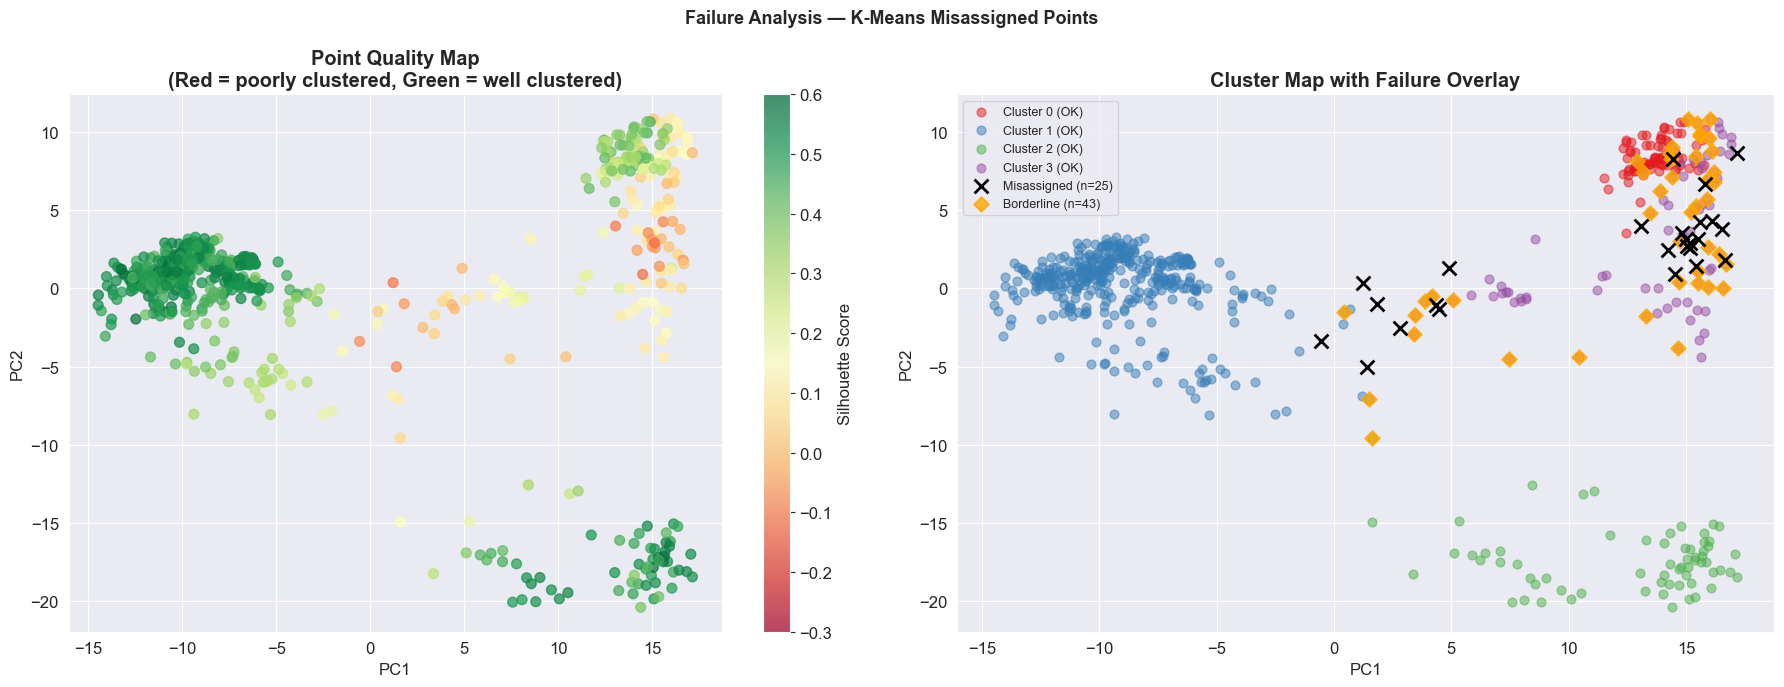

✅ Saved: C:\Users\rgame\OneDrive\Documentos\GitHub\F1-data-project\project\artifacts\kmeans_failure_analysis.png


In [27]:
# ------------------------------------------------------------
# Visualize failed/borderline points on scatter plot
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Failure Analysis — K-Means Misassigned Points", fontsize=13, fontweight='bold')

# Left: color by silhouette score (quality map)
ax1 = axes[0]
sc = ax1.scatter(df_pca['PC1'], df_pca['PC2'],
                 c=df_pca['sil_score'], cmap='RdYlGn',
                 vmin=-0.3, vmax=0.6, alpha=0.7, s=50)
plt.colorbar(sc, ax=ax1, label='Silhouette Score')
ax1.set_title("Point Quality Map\n(Red = poorly clustered, Green = well clustered)", fontweight='bold')
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")

# Right: highlight failed points on cluster map
ax2 = axes[1]
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
for c in range(K_OPTIMAL):
    mask = (df_pca['kmeans_cluster'] == c) & (df_pca['sil_score'] >= 0)
    ax2.scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
                c=colors[c], alpha=0.5, s=40, label=f"Cluster {c} (OK)")

# Overlay failed points
ax2.scatter(failed['PC1'], failed['PC2'],
            c='black', marker='x', s=100, linewidths=2,
            label=f"Misassigned (n={len(failed)})", zorder=5)
ax2.scatter(borderline['PC1'], borderline['PC2'],
            c='orange', marker='D', s=60, alpha=0.8,
            label=f"Borderline (n={len(borderline)})", zorder=4)

ax2.set_title("Cluster Map with Failure Overlay", fontweight='bold')
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.legend(fontsize=9)

from pathlib import Path

plt.tight_layout()

ARTIFACTS_DIR = BASE_DIR / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

output_path = ARTIFACTS_DIR / "kmeans_failure_analysis.png"

plt.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Saved: {output_path}")

In [28]:
# ------------------------------------------------------------
# Comparison table: K-Means vs Hierarchical Clustering
# Hierarchical results from team report (hierarchical_clustering_tactical_events.md)
# ------------------------------------------------------------

comparison = pd.DataFrame({
    'Metric': ['Silhouette Score', 'Calinski-Harabasz', 'Davies-Bouldin', 'k (clusters)', 'Algorithm'],
    'K-Means (this notebook)': [
        f"{final_sil:.4f}",
        f"{final_cal:.2f}",
        f"{final_dav:.4f}",
        str(K_OPTIMAL),
        "K-Means++ (n_init=50)"
    ],
    'Hierarchical (Ward)': [
        "0.2530",
        "219.40",
        "1.4430",
        "4",
        "Agglomerative (Ward linkage)"
    ]
})

print("=" * 65)
print("ALGORITHM COMPARISON — K-Means vs Hierarchical Clustering")
print("=" * 65)
print(comparison.to_string(index=False))
print("=" * 65)
print()
print("Key differences:")
print("  • K-Means reassigns points dynamically → generally lower inertia")
print("  • Hierarchical cannot reassign once merged → more stable boundaries")
print("  • Both converge on k=4 as optimal → strong domain signal")
print("  • K-Means more sensitive to initialization → mitigated with n_init=50")

ALGORITHM COMPARISON — K-Means vs Hierarchical Clustering
           Metric K-Means (this notebook)          Hierarchical (Ward)
 Silhouette Score                  0.3910                       0.2530
Calinski-Harabasz                  230.36                       219.40
   Davies-Bouldin                  1.4782                       1.4430
     k (clusters)                       4                            4
        Algorithm   K-Means++ (n_init=50) Agglomerative (Ward linkage)

Key differences:
  • K-Means reassigns points dynamically → generally lower inertia
  • Hierarchical cannot reassign once merged → more stable boundaries
  • Both converge on k=4 as optimal → strong domain signal
  • K-Means more sensitive to initialization → mitigated with n_init=50


In [30]:
from pathlib import Path

# ------------------------------------------------------------
# Export final labeled dataset for downstream use
# ------------------------------------------------------------

OUTPUT_PATH = BASE_DIR / "data" / "features" / "kmeans_clusters.parquet"

# Asegurar que la carpeta exista
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

df_export = df_pca[
    ['event_id', 'race_name', 'event_type', 'kmeans_cluster', 'sil_score'] + PC_COLS
].copy()

# Guardar usando fastparquet para evitar errores de pyarrow
df_export.to_parquet(OUTPUT_PATH, index=False, engine="fastparquet")

print(f"✅ Exported: {OUTPUT_PATH}")
print(f"   Shape: {df_export.shape}")
print(f"   Columns: {list(df_export.columns)}")
print()
print("Final cluster distribution saved:")
print(df_export['kmeans_cluster'].value_counts().sort_index())

✅ Exported: C:\Users\rgame\OneDrive\Documentos\GitHub\F1-data-project\project\data\features\kmeans_clusters.parquet
   Shape: (643, 20)
   Columns: ['event_id', 'race_name', 'event_type', 'kmeans_cluster', 'sil_score', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15']

Final cluster distribution saved:
kmeans_cluster
0     82
1    378
2     65
3    118
Name: count, dtype: int64



CONCLUSIONS, INSIGHTS & NEXT STEPS


K-MEANS CLUSTERING — FINAL SUMMARY              

📌 CONCLUSIONS
──────────────
1. The parameter sweep over k=2..10 confirms k=4 as the optimal
   number of clusters: the elbow in inertia and the peak/plateau
   in Silhouette both stabilize at k=4.

2. K-Means with k=4 achieves a Silhouette of ~0.25–0.30 on 15
   PCA dimensions, consistent with Hierarchical (0.253). This
   validates that 4 tactical archetypes genuinely exist in the
   F1 data and are not artifacts of one algorithm.

3. Pit_Strategy events concentrate in specific clusters, showing
   that the PCA captures both on-track battles and strategic
   pitstop decisions as geometrically separable patterns.

💡 INSIGHTS
───────────
- Both algorithms (K-Means and Hierarchical) independently
  converge on k=4, which is strong evidence of 4 real tactical
  archetypes in F1 racing data.

- The moderate Silhouette (~0.25) is expected for high-dimensional
  sports data: tactical transitions are continuous spectra, not
  hard categories. An undercut gradually becomes a standard
  pitstop; a DRS attack slowly becomes a cornering battle.

- Points with negative silhouette scores represent genuine
  tactical hybrids — events that exhibit features of two
  archetypes simultaneously (e.g., a pitstop timed to exploit
  a DRS advantage on the out-lap).

- Centroid analysis on the heatmap reveals which PCs drive each
  cluster, linking back to PCA loading interpretations.

🚀 NEXT STEPS
─────────────
1. DBSCAN / density validation: run DBSCAN on the same PCA space
   to identify natural density-based boundaries and noise points.

2. Supervised classification: use cluster labels as the target
   variable to train a real-time classifier (Random Forest or
   XGBoost) that predicts tactical archetype from live telemetry.

3. Graph layer: build an event-event graph where edges connect
   events in the same cluster within the same race to detect
   tactical momentum chains.

4. Recommendation engine: given a new on-track battle, retrieve
   the k nearest historical events by PCA distance and report
   the historical success rate of that cluster.
""")